# Question 4: Joint Distribution of \( P_1 \)
This notebook calculates the joint distribution of the vector:
\[
P_1 = \left(FX_1, V_1^{US,local}, V_1^{EUR}, Z_1^{USD,4Y,local}, Z_1^{EUR,4Y}\right)^\top
\]

We simulate the evolution of these components over one year using Monte Carlo methods. The simulation is based on:
1. Initial values for FX rates, asset values, and yields.
2. A covariance matrix defining the dependencies between variables.
3. Analytical and visual validation of the results.


In [41]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal

# Load data
init_values = pd.read_excel("init_values.xlsx", index_col=0)
covariance_matrix = pd.read_excel("covariance_matrix.xlsx", index_col=0)

# Display loaded data for verification
print("Initial Values:")
print(init_values)
print("\nCovariance Matrix:")
print(covariance_matrix)

# Parameters
time_steps = 52  # Weekly time steps
num_simulations = 10000  # Number of simulations
horizon = 1  # One year
dt = horizon / time_steps

Initial Values:
         initial values
fx_spot        0.055293
EQV US         0.000000
EQV EUR        0.000000
1M EUR         0.031221
1Y EUR         0.022467
3Y EUR         0.019712
5Y EUR         0.020047
7Y EUR         0.020564
10Y EUR        0.021388
1M USD         0.045792
1Y USD         0.041673
3Y USD         0.038207
5Y USD         0.037409
7Y USD         0.037250
10Y USD        0.037381

Covariance Matrix:
              fx_spot        EQV US       EQV EUR        1M EUR        1Y EUR  \
fx_spot  1.127795e-04  3.842035e-05 -4.709843e-06  1.470387e-07 -2.010531e-07   
EQV US   3.842035e-05  4.280089e-04  3.360156e-04 -9.502569e-08 -2.105753e-06   
EQV EUR -4.709843e-06  3.360156e-04  4.654483e-04 -5.825107e-08 -1.131132e-06   
1M EUR   1.470387e-07 -9.502569e-08 -5.825107e-08  9.576964e-08  5.264444e-08   
1Y EUR  -2.010531e-07 -2.105753e-06 -1.131132e-06  5.264444e-08  3.316056e-07   
3Y EUR  -3.944625e-07 -3.033449e-06 -1.659849e-06  2.276903e-08  4.133445e-07   
5Y EUR  -3.89

In [37]:
# Function to simulate P1
def simulate_P1(init_values, covariance_matrix, num_simulations=10000, time_steps=52, horizon=1):
    initial_values = init_values['initial values'].values.flatten()
    mu = np.zeros(covariance_matrix.shape[0])  # Zero drift for simplicity
    sigma = covariance_matrix.values  # Covariance matrix

    # Monte Carlo simulation
    paths = np.zeros((num_simulations, time_steps + 1, len(initial_values)))
    paths[:, 0, :] = initial_values

    dt = horizon / time_steps  # Time step size

    for t in range(1, time_steps + 1):
        delta_x = np.random.multivariate_normal(mu * dt, sigma * dt, size=num_simulations)
        paths[:, t, :] = paths[:, t-1, :] + delta_x

    return paths

# Simulate paths for P1
paths = simulate_P1(init_values, covariance_matrix, num_simulations, time_steps, horizon)


In [38]:
# Calculate bond prices
def calculate_bond_prices(yields, maturities):
    return np.exp(-yields * maturities)

# Extract components of P1
FX_1 = paths[:, -1, 0]  # FX rate
V_US_local = paths[:, -1, 1]
V_EUR = paths[:, -1, 2]

# Bond yields and maturities
USD_yields = paths[:, -1, 3]
EUR_yields = paths[:, -1, 4]

# Calculate bond prices for 4-year bonds
Z_US_4Y = calculate_bond_prices(USD_yields, 4)
Z_EUR_4Y = calculate_bond_prices(EUR_yields, 4)

# Construct P1
P1 = np.column_stack([FX_1, V_US_local, V_EUR, Z_US_4Y, Z_EUR_4Y])

In [39]:
# Validate and visualize
mean_P1 = np.mean(P1, axis=0)
cov_P1 = np.cov(P1.T)

print("Mean of P1:", mean_P1)
print("Covariance matrix of P1:\n", cov_P1)

Mean of P1: [5.52045214e-02 5.57339331e-05 3.39599894e-04 8.82602904e-01
 9.14082527e-01]
Covariance matrix of P1:
 [[ 1.12029025e-04  4.14288265e-05 -2.48312579e-06 -6.53152579e-07
   4.96277011e-07]
 [ 4.14288265e-05  4.19010828e-04  3.28002694e-04  4.68542945e-07
   7.31974587e-06]
 [-2.48312579e-06  3.28002694e-04  4.61182736e-04  2.10040427e-07
   3.80570649e-06]
 [-6.53152579e-07  4.68542945e-07  2.10040427e-07  1.19903708e-06
   6.78379248e-07]
 [ 4.96277011e-07  7.31974587e-06  3.80570649e-06  6.78379248e-07
   4.41107975e-06]]


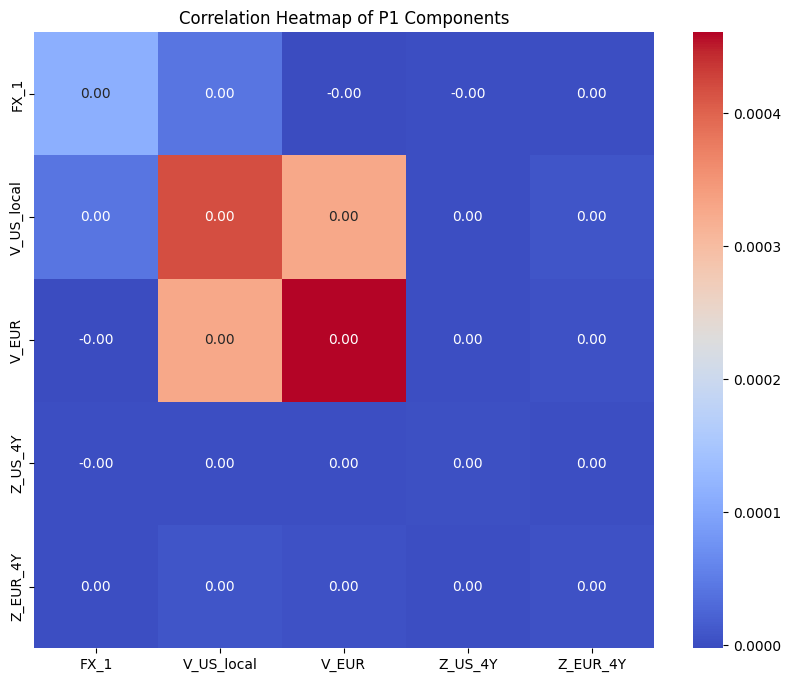

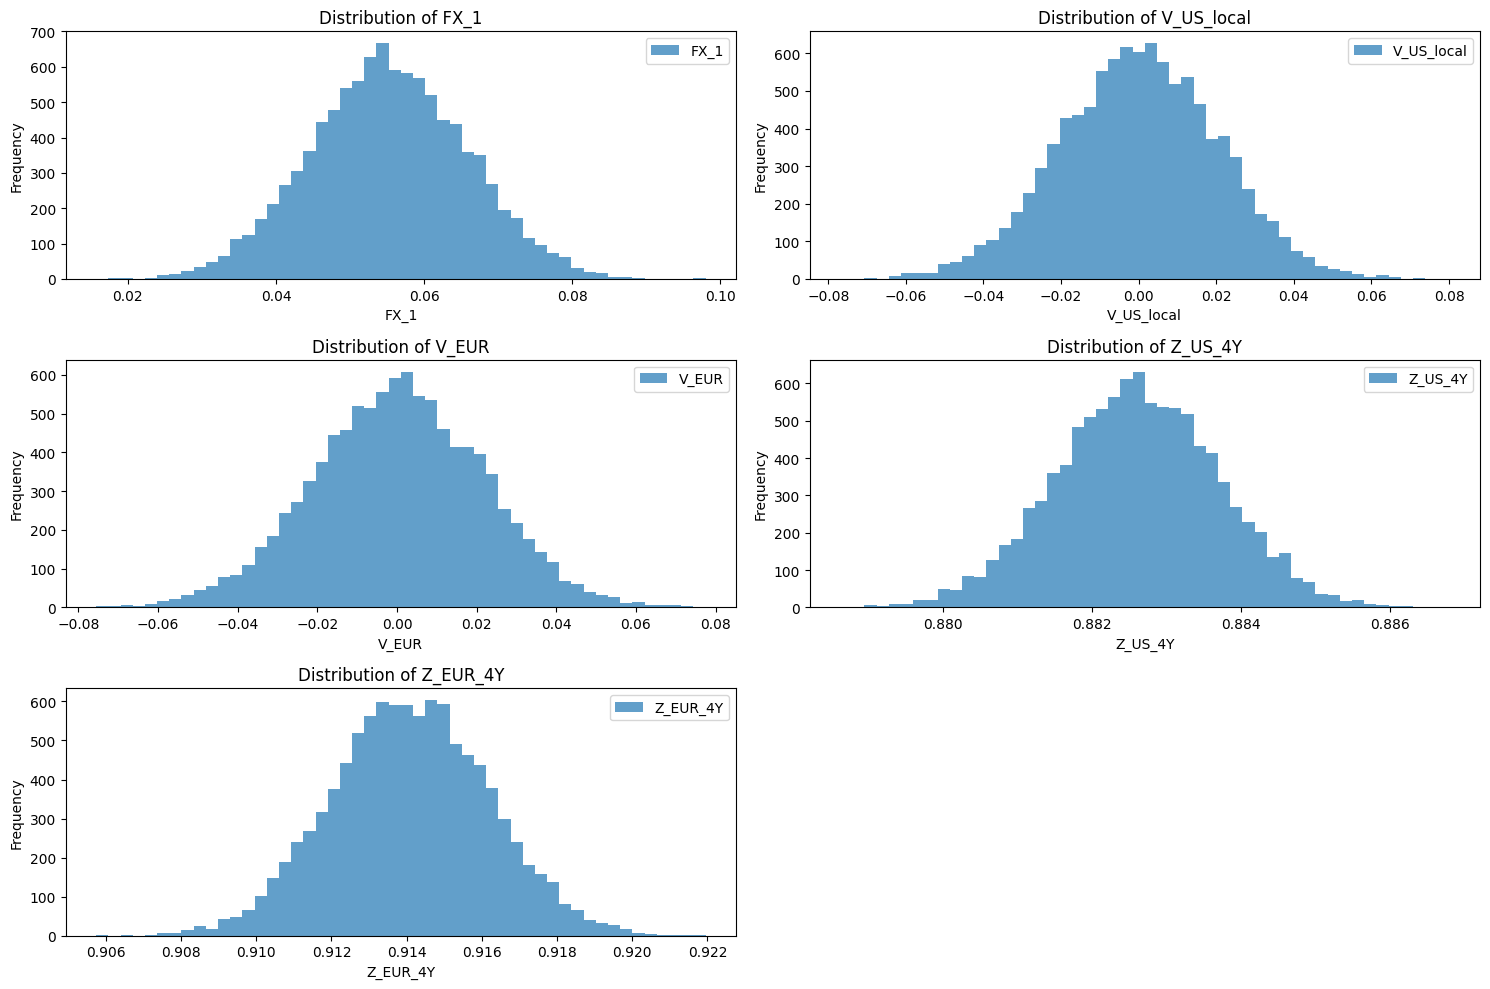

In [40]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cov_P1, annot=True, fmt=".2f",
            xticklabels=["FX_1", "V_US_local", "V_EUR", "Z_US_4Y", "Z_EUR_4Y"],
            yticklabels=["FX_1", "V_US_local", "V_EUR", "Z_US_4Y", "Z_EUR_4Y"],
            cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of P1 Components")
plt.show()

# Histograms for P1 components
components = ["FX_1", "V_US_local", "V_EUR", "Z_US_4Y", "Z_EUR_4Y"]
plt.figure(figsize=(15, 10))
for i, component in enumerate(components):
    plt.subplot(3, 2, i + 1)
    plt.hist(P1[:, i], bins=50, alpha=0.7, label=component)
    plt.title(f"Distribution of {component}")
    plt.xlabel(component)
    plt.ylabel("Frequency")
    plt.legend()
plt.tight_layout()
plt.show()

### Results Summary
1. **Mean of \( P_1 \)**:
   The simulated mean values for the components of \( P_1 \) are calculated and printed above.

2. **Covariance Matrix**:
   The covariance matrix of \( P_1 \) shows the relationships between components. The correlation heatmap visualizes these dependencies.

3. **Distributions**:
   Histograms illustrate the simulated distributions for each component, confirming the spread and behavior of the simulated variables.

### Next Steps
- Replace placeholder data with the actual `init_values.xlsx` and `covariance_matrix.xlsx` data.
- Validate simulations against analytical expectations if applicable.
